# GGTCE — Global GRU Temporal Context Experiment

Input window ablation: G96, G192, G288 (output horizon fixed at 96).

Documentation: `docs/global_window_experiment/`

> Set `EXP_DIR` below to your authoritative run directory.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT))

runs = sorted((REPO_ROOT / 'experiments').glob('ggtce_*'))
EXP_DIR = runs[-1] if runs else None
print('Experiment:', EXP_DIR)

if EXP_DIR is None:
    raise FileNotFoundError('No ggtce_* experiment — run scripts/run_ggtce_experiment.py')

Experiment: /Users/lehaan/Desktop/FYP_Long_Term/experiments/ggtce_2026-07-26_190616


## 1. Introduction

In [2]:
with (EXP_DIR / 'config' / 'ggtce_config_frozen.json').open() as fh:
    config = json.load(fh)
print('Protocol:', config['protocol_version'])
print('RQ:', config['research_question'])
print('Co-primary:', config['co_primary_question'])

Protocol: ggtce_v1.0
RQ: Does increasing the historical input window of the Global GRU improve long-term CPU forecasting because additional temporal memory exists beyond the current 96-step window?
Co-primary: Do workloads with stronger long-range temporal dependence benefit more from longer input windows?


## 2. Methodology & frozen parity

In [3]:
with (EXP_DIR / 'verification' / 'frozen_parity.json').open() as fh:
    parity = json.load(fh)
pd.DataFrame(parity['checks'])

,check,passed,detail
0,same_train_parquet_hash,True,train hash=515fd6d7bc3302db...
1,same_val_parquet_hash,True,val hash=553156e7831acd34...
2,same_selected_containers,False,n_frozen=99 n_current=100
3,scalers_present,True,/Users/lehaan/Desktop/FYP_Long_Term/data/scale...
4,g96_sequence_count_expected,True,g96 total=41749
5,g192_sequence_count_expected,True,g192 total=32245
6,g288_sequence_count_expected,True,g288 total=22741
7,only_input_window_differs,True,"Architecture, optimizer, loss, batch, epochs f..."


## 3. G96 replication gate

In [4]:
with (EXP_DIR / 'verification' / 'g96_replication.json').open() as fh:
    rep = json.load(fh)
rep

{'passed': True,
 'mean_mae_ggtce': 1.9242406355693225,
 'mean_mae_frozen': 1.9242406355693225,
 'mean_mae_abs_delta': 0.0,
 'rank_corr_spearman': 0.9999999999999999,
 'tolerance': {'mean_mae_abs_delta': 0.05, 'rank_corr_min': 0.95},
 'per_container_delta_mae_mean': 0.0,
 'per_container_delta_mae_max': 0.0}

## 4. Training

In [5]:
seq = pd.read_csv(EXP_DIR / 'sequence_analysis' / 'sequence_reduction.csv')
seq

,variant_id,input_window,n_sequences,n_train_sequences,training_seconds,best_epoch,epochs_run,mean_per_container_sequences,mean_day1_mae,mean_forecast_pearson_r
0,g96,96,41650,33320,177.458363,25,35,421.707071,1.924241,0.415500
1,g192,192,32146,25716,107.397433,7,17,325.707071,2.254945,0.277762
2,g288,288,22642,18113,284.766568,36,46,229.707071,2.099344,0.377303


## 5. Evaluation

In [6]:
cohort = pd.read_csv(EXP_DIR / 'window_comparison' / 'cohort_comparison.csv')
cohort

,variant_id,n,mean_day1_mae,mean_day1_rmse,mean_day1_mape,mean_forecast_mae_scaled,mean_forecast_rmse_scaled,mean_forecast_pearson_r,mean_forecast_r2,mean_forecast_std_ratio
0,g96,99,1.924241,2.610536,116.502574,0.103245,0.150885,0.415500,0.062647,0.517161
1,g192,99,2.254945,2.946503,121.621597,0.115558,0.163551,0.277762,-0.121644,0.498392
2,g288,99,2.099344,2.842673,114.817172,0.109844,0.159454,0.377303,-0.003657,0.536733


## 6. Window comparison

In [7]:
deltas = pd.read_csv(EXP_DIR / 'window_comparison' / 'deltas_g96_to_g288.csv')
deltas.describe()

,delta_day1_mae,delta_day1_rmse,delta_day1_mape,delta_forecast_mae_scaled,delta_forecast_rmse_scaled,delta_forecast_pearson_r,delta_forecast_r2,delta_forecast_std_ratio
count,99.000000,99.000000,99.000000,99.000000,99.000000,97.000000,97.000000,97.000000
mean,0.175104,0.232137,-1.685403,0.006599,0.008569,-0.038197,-0.066304,0.019572
std,0.516559,0.573334,19.246083,0.015827,0.017202,0.113568,0.297579,0.085841
min,-2.525442,-2.602340,-169.492903,-0.082801,-0.085323,-0.546084,-0.711954,-0.311816
25%,-0.000212,0.005313,-0.631745,-0.000248,0.001324,-0.079168,-0.146125,-0.026075
50%,0.070182,0.088588,0.392934,0.004766,0.004662,-0.020317,-0.072348,0.009324
75%,0.284150,0.380941,1.899512,0.009979,0.015200,0.020030,-0.013322,0.054709
max,3.033906,3.443825,53.634803,0.056532,0.064171,0.201260,2.207506,0.259705


## 7. Memory-aware analysis

In [8]:
mem = pd.read_csv(EXP_DIR / 'memory_analysis' / 'merged_deltas_g96_g288.csv')
mem[['container_id','memory_score','memory_class','delta_day1_mae']].head(10)

,container_id,memory_score,memory_class,delta_day1_mae
0,c_10032,0.418743,low,-0.017940
1,c_10034,0.642031,medium,-2.525442
2,c_10089,0.668954,high,0.300960
3,c_10132,0.687009,high,0.003008
4,c_1016,0.570663,low,0.063443
5,c_10306,0.680424,high,-0.006858
6,c_10312,0.723010,high,-0.071440
7,c_10382,0.662442,medium,0.047390
8,c_10393,0.660470,medium,0.143341
9,c_10641,0.578636,low,0.154837


## 8. Case studies

In [9]:
with (EXP_DIR / 'case_studies' / 'case_studies.json').open() as fh:
    cases = json.load(fh)
cases['cases']

{'largest_improvement': {'container_id': 'c_10034',
  'baseline_mae': 5.603144977655675,
  'compare_mae': 3.077703162575037,
  'delta_mae': -2.525441815080638,
  'memory_score': 0.6420311811492786,
  'memory_class': 'medium',
  'acf_lag_96': 0.782272177561452,
  'acf_lag_192': 0.6152337289209355,
  'acf_lag_288': 0.492697527475436,
  'explanation': 'Longer window (g288) reduced MAE by 2.525 pp vs g96 (5.603→3.078). Memory class=medium, score=0.642, ACF@96=0.782, ACF@288=0.493. Extended temporal context likely captured slow cycles missed by G96.'},
 'median_improvement': {'container_id': 'c_13873',
  'baseline_mae': 1.7922796201374795,
  'compare_mae': 1.862461369898584,
  'delta_mae': 0.07018174976110436,
  'memory_score': 0.19034243948917073,
  'memory_class': 'low',
  'acf_lag_96': 0.02277343249066334,
  'acf_lag_192': -0.0203019782237826,
  'acf_lag_288': -0.01133838416128812,
  'explanation': 'Representative cohort shift (Δ MAE=0.070). Memory class=low, score=0.190, ACF@96=0.023, A

## 9. Visualizations

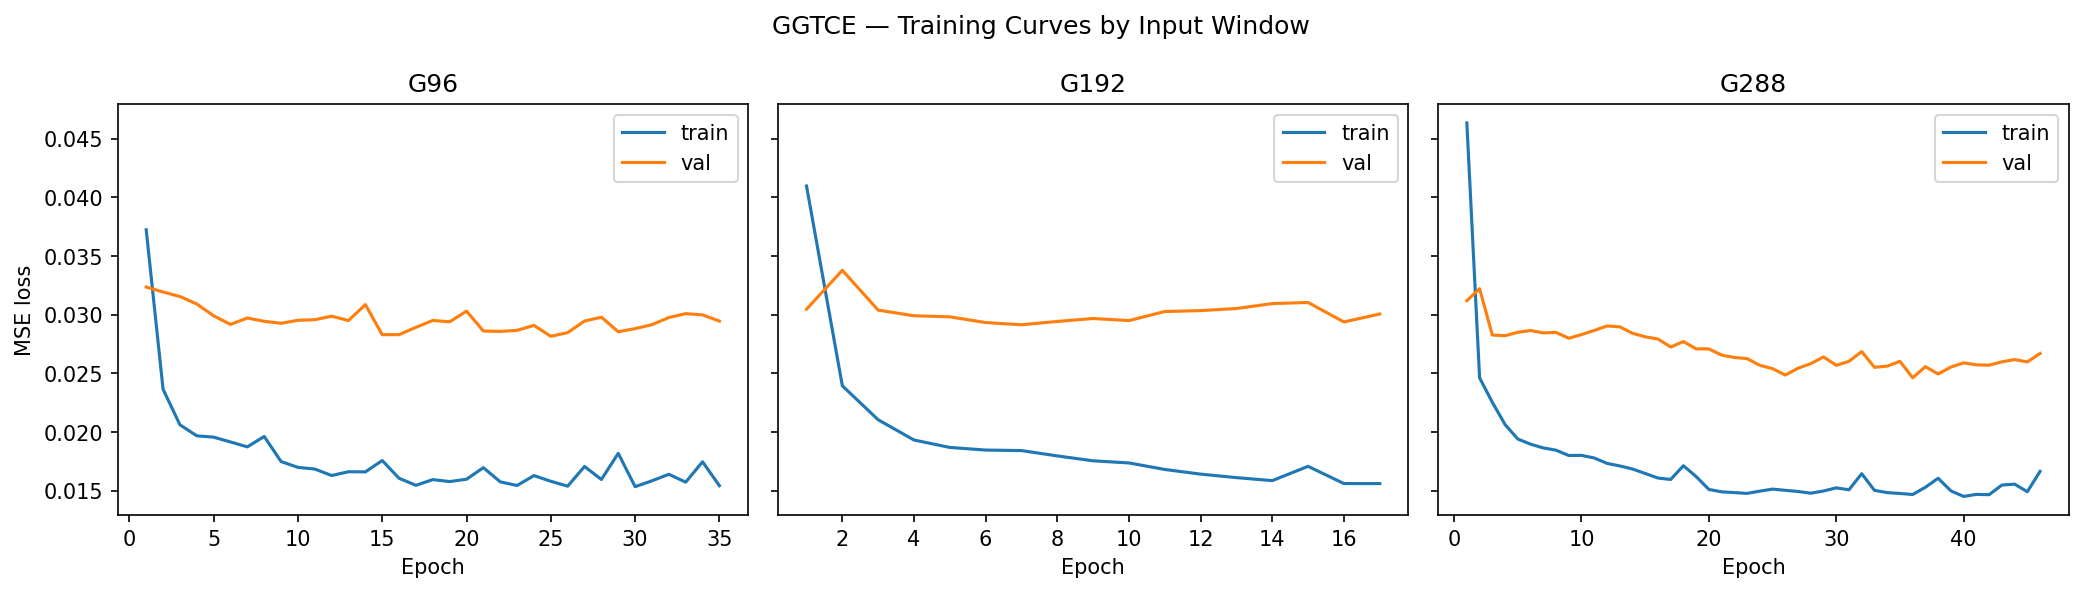

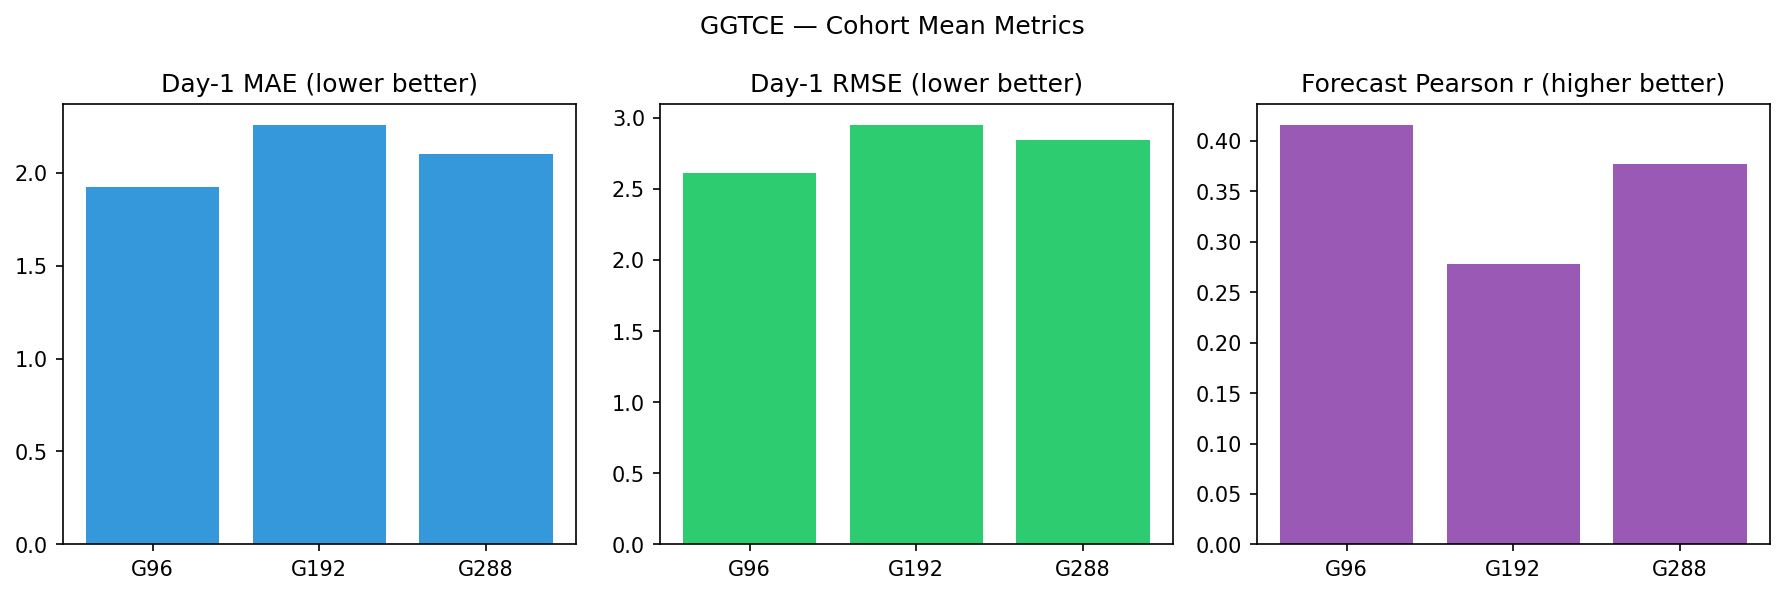

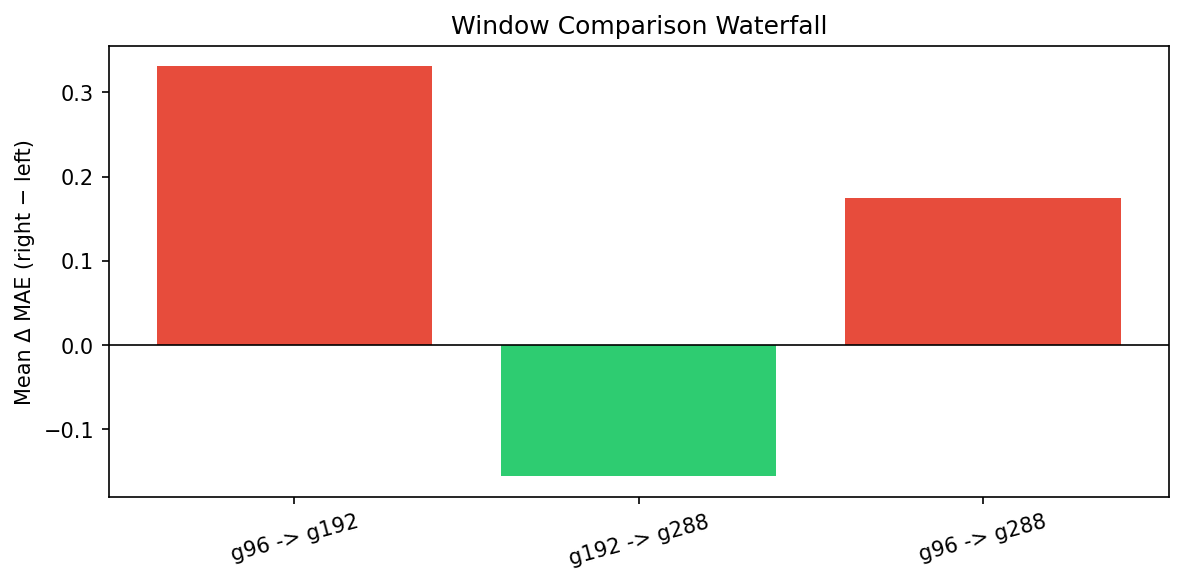

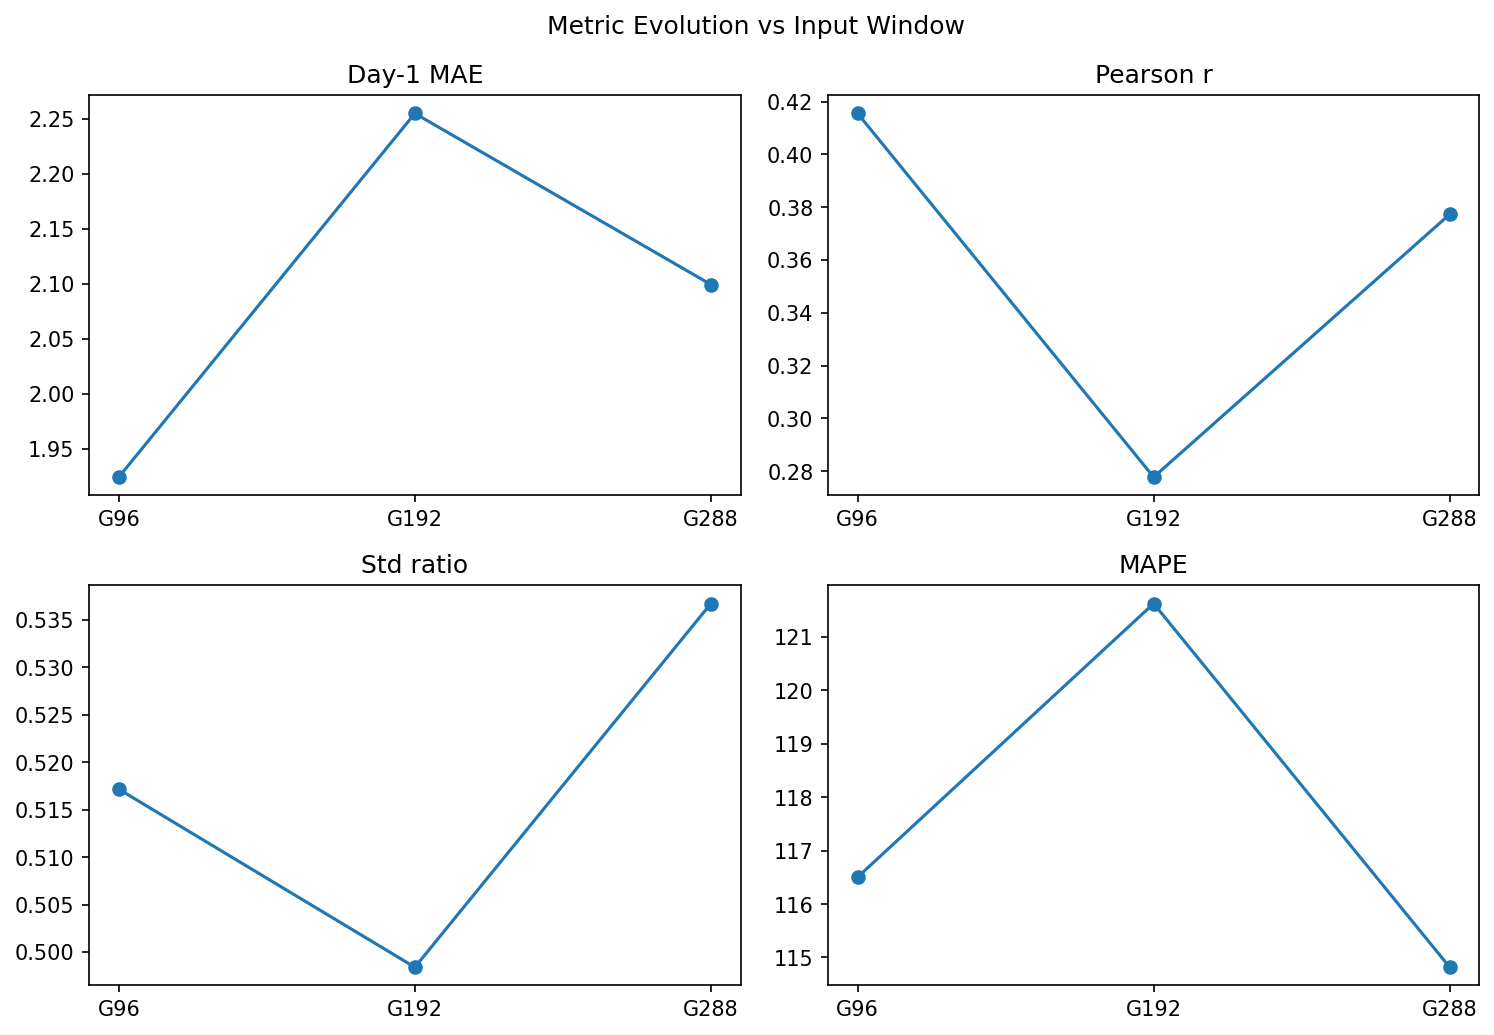

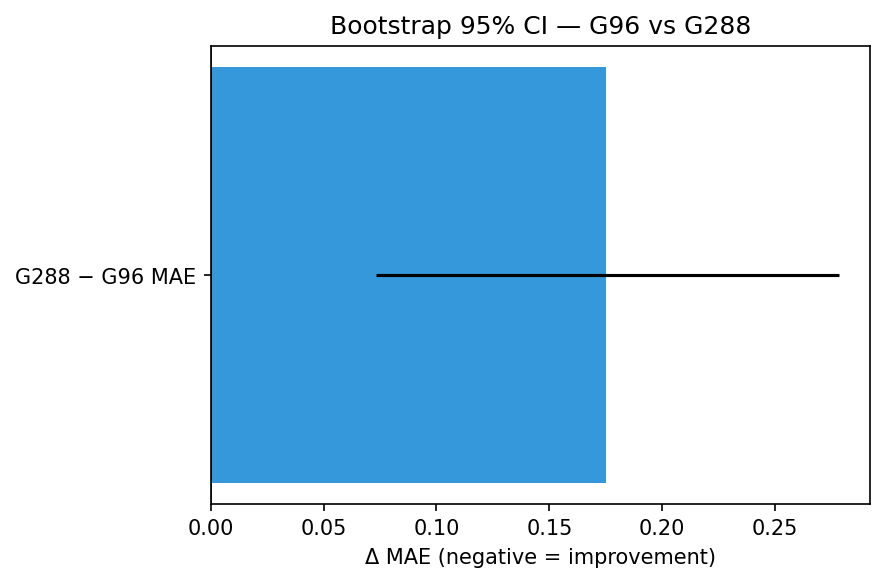

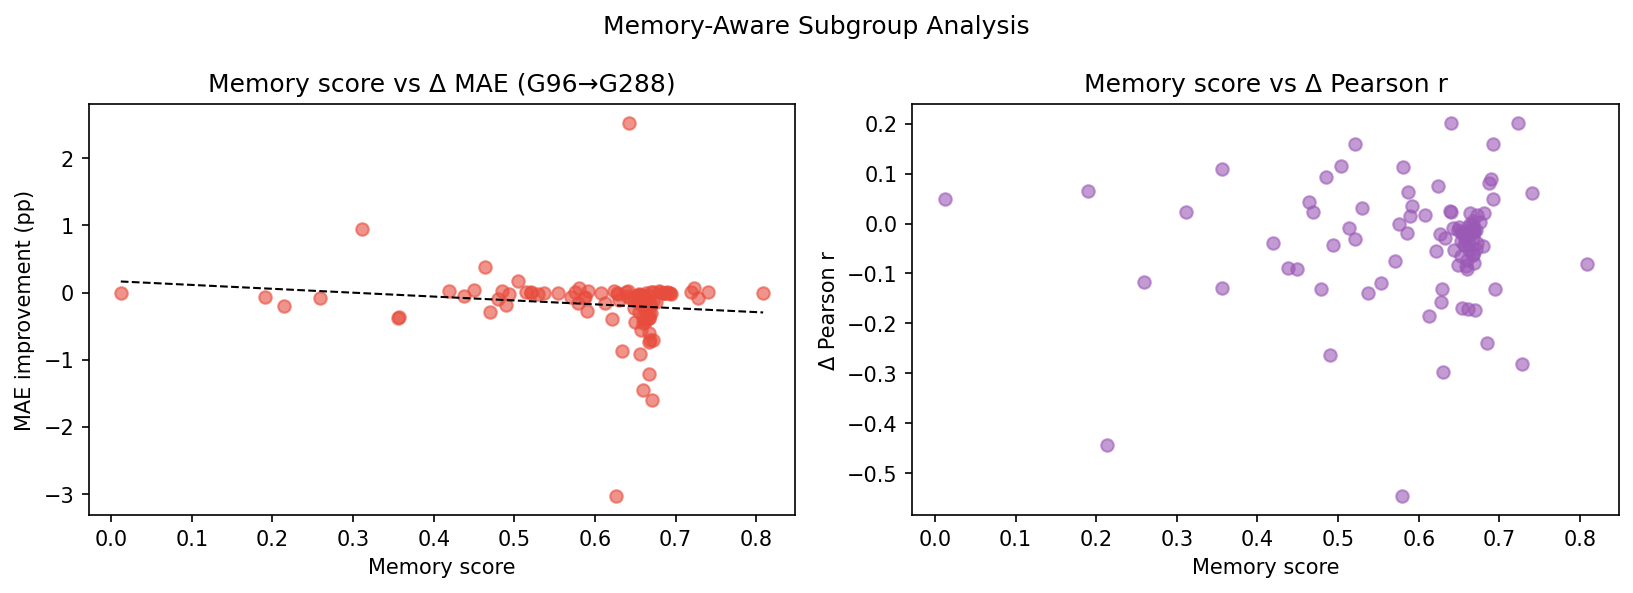

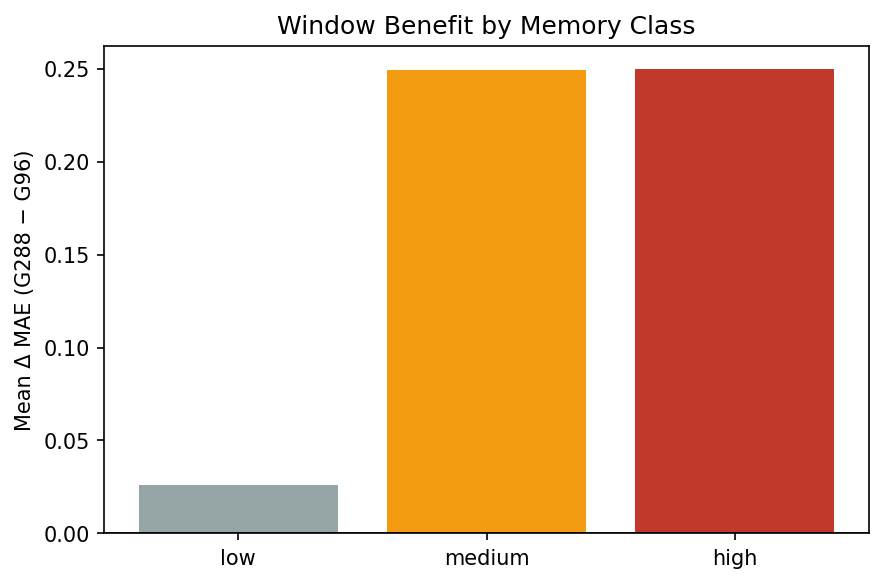

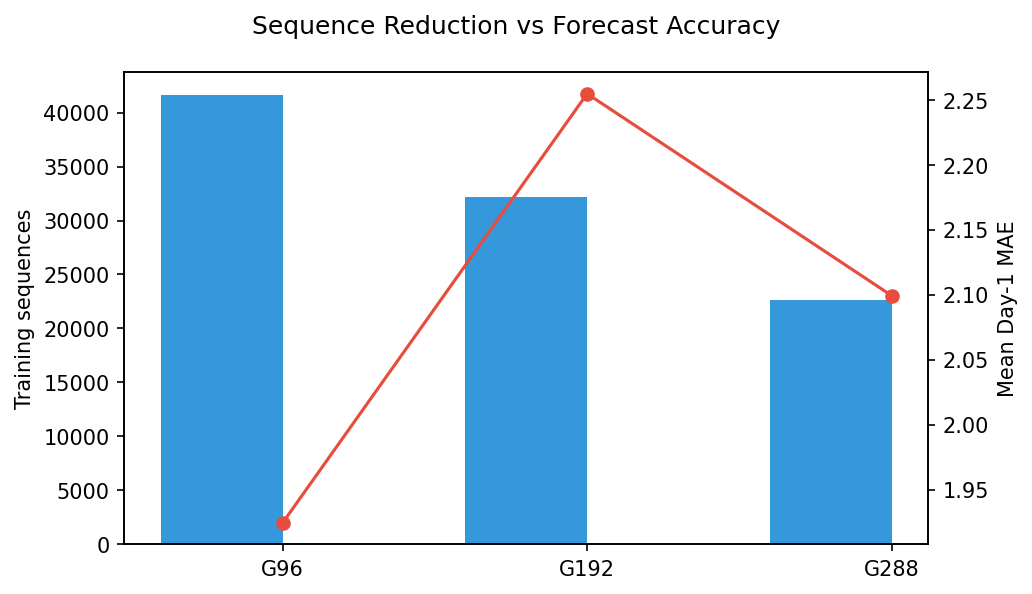

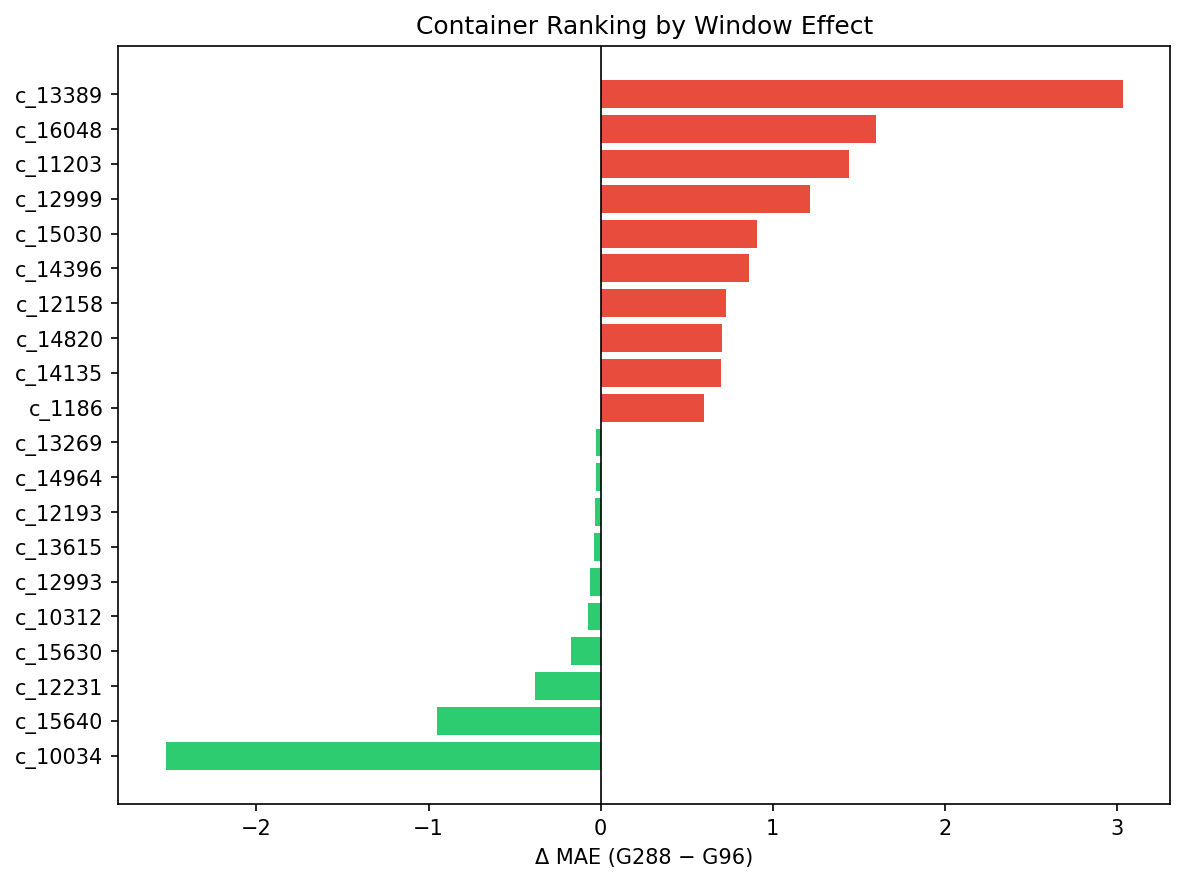

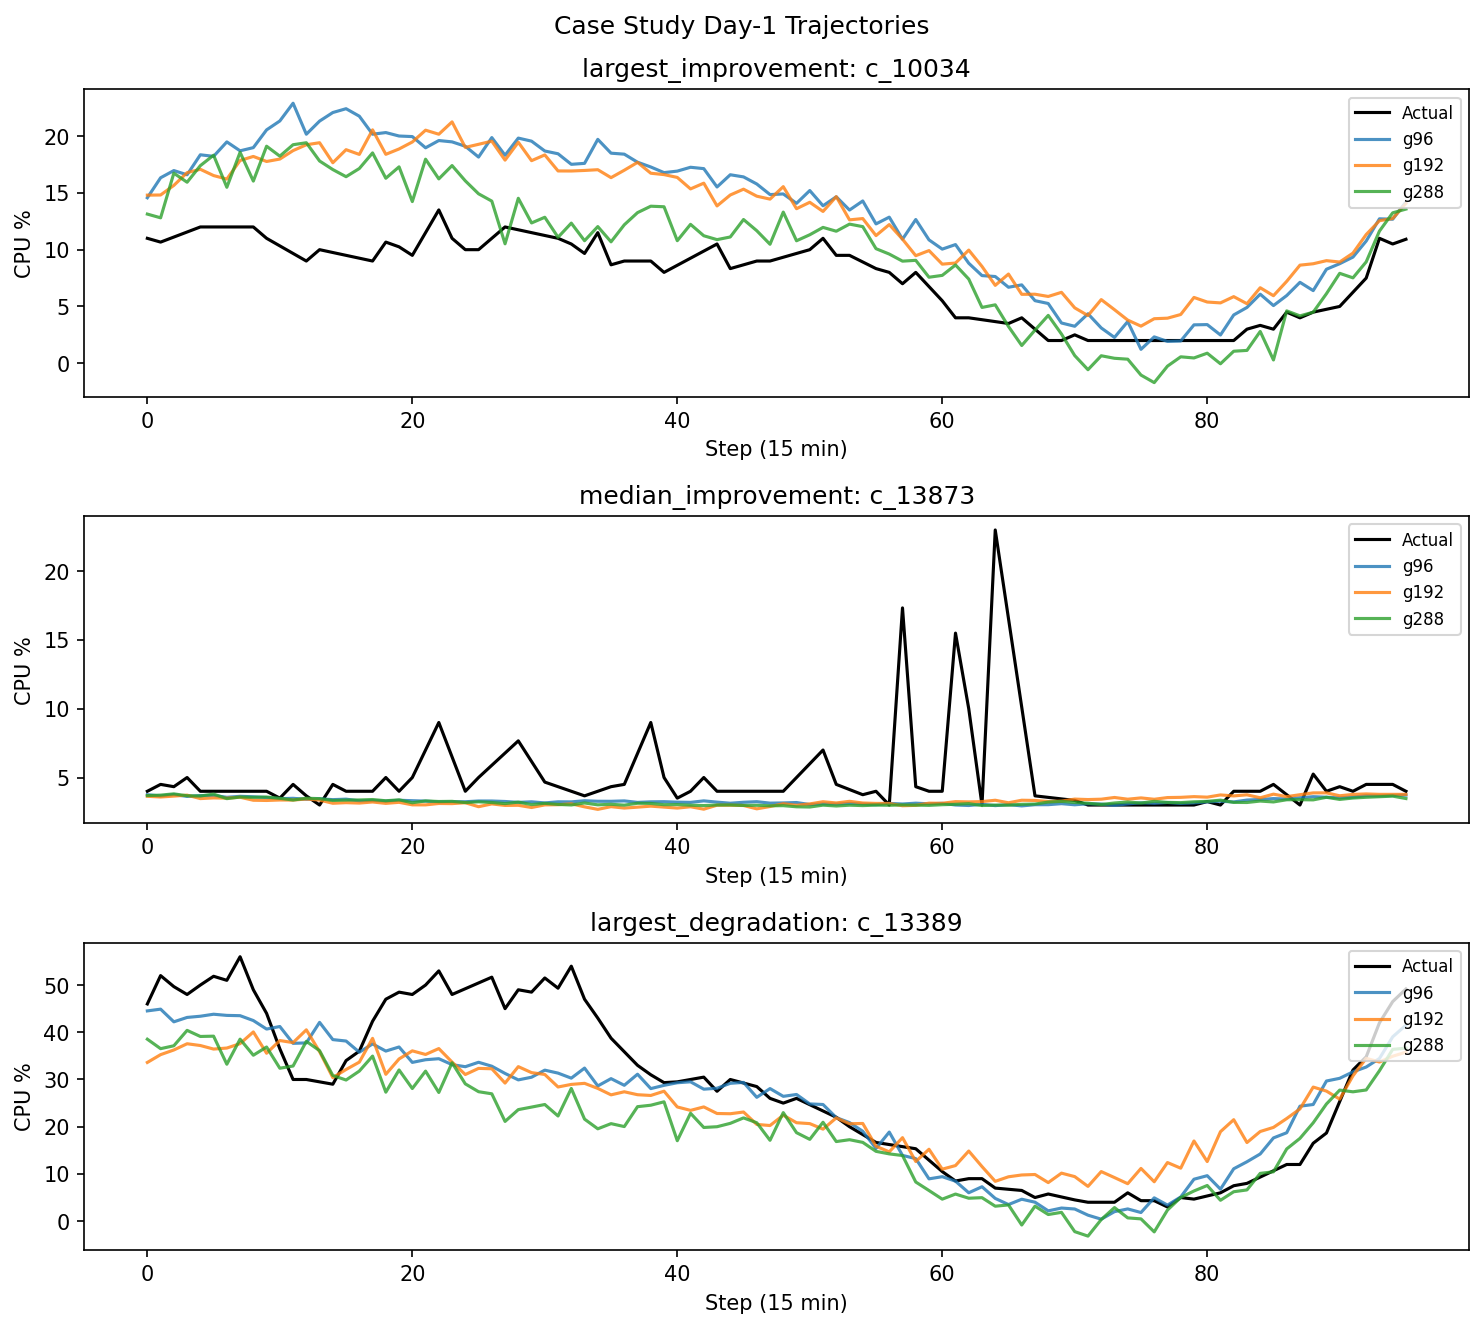

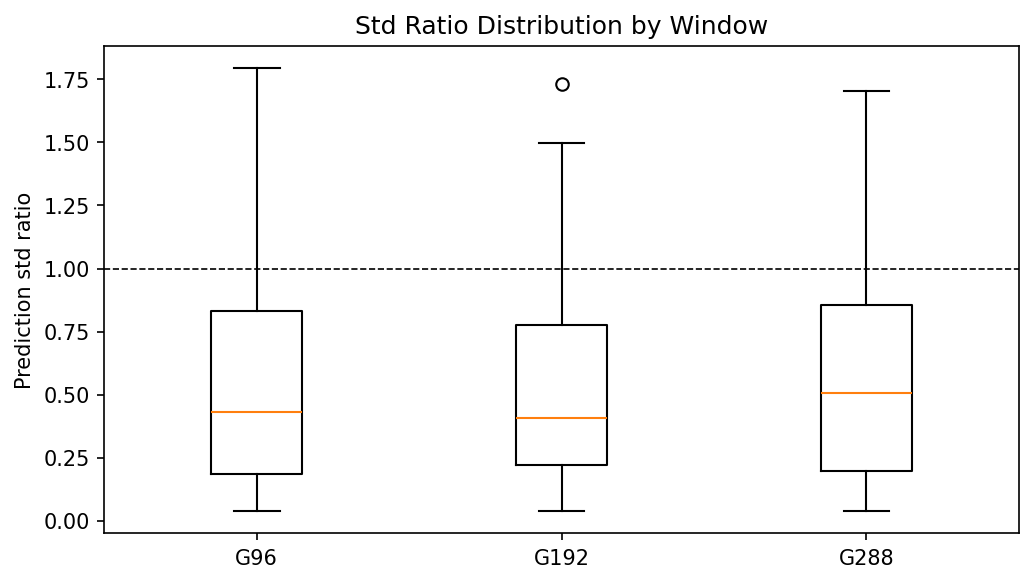

In [10]:
for name in sorted((EXP_DIR / 'plots').glob('*.png')):
    display(Image(filename=str(name)))

## 10. Discussion & conclusions

In [11]:
with (EXP_DIR / 'reports' / 'final_report.json').open() as fh:
    report = json.load(fh)
for k, v in report['final_answers'].items():
    print(f'{k}: {v}')

1_does_longer_window_improve: No — G96 vs G96 MAE 1.924→1.924 (+0.00%)
2_best_input_window: G96 (G96 — Input 96 (baseline reproduction)) — mean Day-1 MAE=1.924
3_statistically_significant: Yes (G96→G288 bootstrap/Wilcoxon on MAE; mean Δ=0.1751)
4_practically_meaningful: No (|MAE change|=0.00%, threshold 1%)
5_high_memory_benefit_more: No / inconclusive — memory–ΔMAE Pearson r=-0.140; low-memory gain negligible: False
6_diminishing_returns: Evidence of diminishing returns after 192 (|Δ| G96→G192=0.3307, G192→G288=0.1556)
7_context_vs_sequence_tradeoff: G96 sequences=41650, g96=41650 (0.0% reduction). Accuracy did not improve despite fewer samples.
8_replace_global_baseline: Keep G96 baseline
9_production_recommendation: Keep frozen G96 Global GRU — longer windows did not justify complexity/cost
10_relation_to_tma: TMA showed 40–73% squared-ACF capture at 96–288 lags; GGTCE tests whether exploiting that memory improves forecasts. High-memory subgroup did not consistently gain more than l